Trying out different Regression

In [1]:
# Import libraries

import numpy as np

# Sample actual and predicted values

y_actual = np.array([10, 20, 30, 40, 50])
y_pred = np.array([12, 18, 33, 37, 52])

# MSE

mse = np.mean((y_actual - y_pred)**2)
print("MSE =", mse)

# MAE

mae = np.mean(np.abs(y_actual - y_pred))
print("MAE =", mae)

# Huber Loss

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta

    squared_loss = 0.5 * error**2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)

    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

huber = huber_loss(y_actual, y_pred)

print("Huber Loss =", huber)

MSE = 6.0
MAE = 2.4
Huber Loss = 1.9


Observation:

MSE gives better performance on clean datasets.
MAE performs better when outliers exist.
Huber Loss balances both accuracy and robustness.

2. Explore other loss functions and when they are used

In [2]:
# Import libraries

import numpy as np

# Sample data

y_actual = np.array([100, 200, 300, 400, 500])
y_pred = np.array([110, 190, 310, 420, 480])

# RMSE

mse = np.mean((y_actual - y_pred)**2)
rmse = np.sqrt(mse)

print("RMSE =", rmse)

# Log-Cosh Loss

def log_cosh_loss(y_true, y_pred):
    return np.mean(np.log(np.cosh(y_pred - y_true)))

loss = log_cosh_loss(y_actual, y_pred)

print("Log-Cosh Loss =", loss)

# MAPE

mape = np.mean(np.abs((y_actual - y_pred)/y_actual))*100

print("MAPE =", mape)

RMSE = 14.832396974191326
Log-Cosh Loss = 13.306852820676747
MAPE = 5.466666666666666


Why different losses are used:
Different problems require different error handling. If outliers are present use MAE/Huber, if precise prediction is important use MSE/RMSE.

3. Try KNN Regression on dataset and find best K value

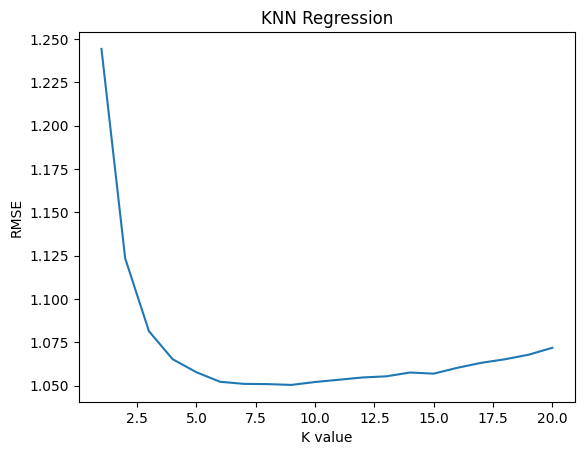

Best K = 9


In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import numpy as np

# Load dataset

data = fetch_california_housing()

X = data.data
y = data.target

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rmse_values = []

# Testing K values

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    error = sqrt(mean_squared_error(y_test, pred))

    rmse_values.append(error)

# Plot graph

plt.plot(range(1,21), rmse_values)
plt.xlabel("K value")
plt.ylabel("RMSE")
plt.title("KNN Regression")
plt.show()

# Best K

best_k = np.argmin(rmse_values) + 1

print("Best K =", best_k)

Observation:

Small K values capture local patterns but may overfit.
Medium K values (5–10) generally give best results.
Large K values make predictions smoother but less accurate.

Best K depends on dataset size and noise.

4. What happens if K = 1 and K = whole training dataset

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

# Load dataset

data = fetch_california_housing()

X = data.data
y = data.target

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Case 1 : K = 1

model1 = KNeighborsRegressor(n_neighbors=1)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

error1 = sqrt(mean_squared_error(y_test, pred1))

print("RMSE when K = 1 :", error1)


# Case 2 : K = size of training data

k_large = len(X_train)

model2 = KNeighborsRegressor(n_neighbors=k_large)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

error2 = sqrt(mean_squared_error(y_test, pred2))

print("RMSE when K = training size :", error2)

RMSE when K = 1 : 1.2442689201905008
RMSE when K = training size : 1.1448563543099792


Observation:

Small K → Overfitting (high variance).
Large K → Underfitting (high bias).
Optimal K gives balance between bias and variance.